# Projeto Aplicado III 

**Disciplina**: Projeto Aplicado III - Mackenzie
**Objetivo**: Criar um Sistema de Recomendação usando K-Means (Sem NLP)
**Alinhamento** ODS: ODS 3 - Saúde e Bem-Estar

## Preparação do Modelo

### Entendimento do Negócio 

Ver `Projeto Aplicado III.pdf` para melhores informações.

O objetivo da extração é conseguir recomendar medicamentos para determinada condição.

Isso será feito com base no NLP dos reviews e ratings.


### Entendimento dos Dados

Dados extraídos de: <a href=https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018>UCI ML Drug Review dataset</a>

**ATENÇÃO**: Esses dados só devem ser utilizados para fins de estudos de NLP, e não condizem com uso em produção.

" 
    
    This dataset was used for the Winter 2018 Kaggle University Club Hackathon and is now publicly available. See Acknowledgments section for citation and licensing. Note: The types of data and recommendation based solutions provided by the contestants are purely for NLP learning purposes. They are not suitable for a real world drug recommendations solutions.

"

In [25]:
# Instalações necessárias
!pip install -r requirements.txt 

### Preparação de Dados

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Carregar os dados
df = pd.read_csv('./drugsComTest_raw.csv', engine='python', on_bad_lines='skip')
# URL DADOS: https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018

In [27]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


In [28]:
# Comentário: Carregamos o dataset oficial da UCI. Como o foco é a recomendação por condição médica, precisamos garantir que essa coluna não tenha nulos.
print(f"Dataset original: {df.shape[0]} registros.")
df = df.dropna(subset=['condition'])
print(f"Dataset após remover nulos: {df.shape[0]} registros.")


Dataset original: 53766 registros.
Dataset após remover nulos: 53471 registros.


#### Análise Exploratória (EDA)

Comentário: Antes de treinar o modelo, precisamos entender o comportamento das avaliações. Analisamos a distribuição das notas para ver se há viés.

In [29]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 53471 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   uniqueID     53471 non-null  int64
 1   drugName     53471 non-null  str  
 2   condition    53471 non-null  str  
 3   review       53471 non-null  str  
 4   rating       53471 non-null  int64
 5   date         53471 non-null  str  
 6   usefulCount  53471 non-null  int64
dtypes: int64(3), str(4)
memory usage: 3.3 MB


In [31]:
df.describe()

,uniqueID,rating,usefulCount
count,53471.000000,53471.000000,53471.000000
mean,116436.223617,6.976829,28.083634
std,67018.466874,3.286228,36.231706
min,0.000000,1.000000,0.000000
25%,58283.500000,4.000000,6.000000
50%,116369.000000,8.000000,16.000000
75%,174623.500000,10.000000,36.000000
max,232284.000000,10.000000,949.000000


/tmp/ipykernel_410384/4181945744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='magma')


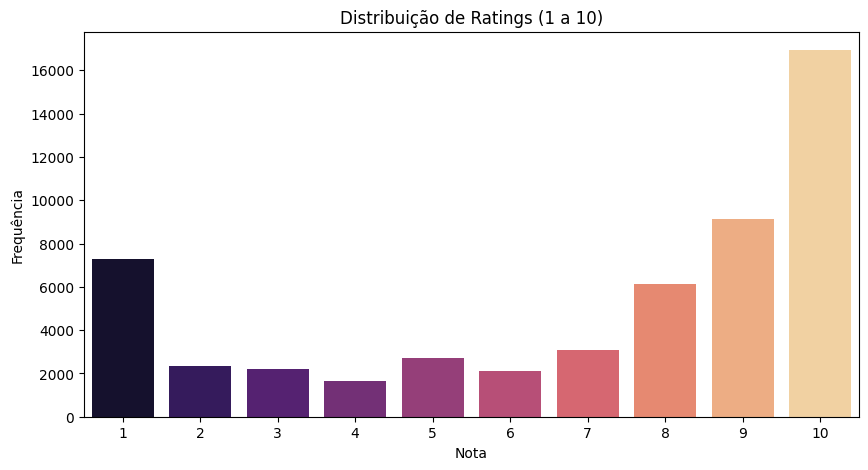

In [32]:

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='rating', palette='magma')
plt.title('Distribuição de Ratings (1 a 10)')
plt.xlabel('Nota')
plt.ylabel('Frequência')
plt.show()

Percebemos que as notas são polarizadas (muitos 10 e muitos 1).
Isso indica que usuários tendem a avaliar quando estão muito satisfeitos ou muito insatisfeitos.

#### Reviews Features Extraction 

Os reviews são em texto livre, conforme abaixo. Em virtude disso, é necessário definir templates para poder transformar esses dados não estruturados em dados processáveis. 

Utilizaremos modelos de LLM para isso, através de modelos gpt-4.1-nano. 

O objetivo é transformar cada review em um conjunto de rubricas / presenças de determinados componentes. 

In [33]:
for x in df['review'].sample(5):
    print(x)
    print("-" * 80)

"Only been on it for a week but my fairly severe ulcerative colitis symptoms have fully subsided. I am taking 1.2g 2 x day. I also started 1200mg of slippery elm and Turmeric 2  days after starting the Lialda. "
--------------------------------------------------------------------------------
"I&#039;m really hesitant to go off of Lo Loestrin after 5 years because, for the most part, I&#039;ve loved it. I used to get crampy periods and since I&#039;ve been on it I get no cramping whatsoever, barely-there periods (I spot just a tiny bit and then that&#039;s it), and no weight gain or moodiness. However, I&#039;ve had such issues with dryness (I can get wet but can&#039;t stay wet during sex) that I think the time has come for me to try a different pill."
--------------------------------------------------------------------------------
"Strattera has changed my life, my relationships, and the way I feel about my self. This drug takes time to get into your system mine took about 2 months, w

In [34]:
from openai import OpenAI
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()  # Carrega as variáveis de ambiente do arquivo .env

client = OpenAI()

class ReviewInformation(BaseModel):
    has_negative_effects: bool
    days_until_effects: int
    solved_the_disease: bool



In [35]:
MODEL_NAME = 'gpt-4.1-nano'

def extract_review_information(review_text: str) -> ReviewInformation:
    review_text = str(review_text) if review_text is not None else ''

    response = client.responses.parse(
        model=MODEL_NAME,
        input=[
            {
                'role': 'system',
                'content': (
                    'Você extrai informações de reviews de medicamentos. '
                    'Retorne somente os campos do schema. '
                    'Se o texto não mencionar em quantos dias houve efeito, use -1 para days_until_effects.'
                ),
            },
            {
                'role': 'user',
                'content': f'Review: {review_text}',
            },
        ],
        text_format=ReviewInformation,
    )

    return response.output_parsed


In [36]:
import os
import asyncio
from openai import AsyncOpenAI

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

OUTPUT_FILE = 'drugComTest_modificado2.csv'
MAX_CONCURRENCY = 50   # ajuste conforme rate limit da API
BATCH_SIZE = 500       # checkpoint de salvamento
SAMPLE_SIZE = None     # None = processa df inteiro

async_client = AsyncOpenAI()

def _fallback_row():
    return {
        'has_negative_effects': False,
        'days_until_effects': -1,
        'solved_the_disease': False,
        '_extract_error': True,
    }

async def extract_review_information_async(review_text: str):
    review_text = str(review_text) if review_text is not None else ''
    response = await async_client.responses.parse(
        model=MODEL_NAME,
        input=[
            {
                'role': 'system',
                'content': (
                    'Você extrai informações de reviews de medicamentos. '
                    'Retorne somente os campos do schema. '
                    'Se o texto não mencionar em quantos dias houve efeito, use -1 para days_until_effects.'
                ),
            },
            {'role': 'user', 'content': f'Review: {review_text}'},
        ],
        text_format=ReviewInformation,
    )
    return response.output_parsed

async def process_one(idx, review_text, semaphore):
    async with semaphore:
        try:
            info = await extract_review_information_async(review_text)
            return idx, {
                'has_negative_effects': info.has_negative_effects,
                'days_until_effects': info.days_until_effects,
                'solved_the_disease': info.solved_the_disease,
                '_extract_error': False,
            }
        except Exception:
            return idx, _fallback_row()

async def enrich_dataframe_async(df_input):
    semaphore = asyncio.Semaphore(MAX_CONCURRENCY)
    results = [None] * len(df_input)

    def build_checkpoint_structured(rows):
        pending_row = {
            'has_negative_effects': None,
            'days_until_effects': None,
            'solved_the_disease': None,
            '_extract_error': None,
            '_pending': True
        }
        normalized = [r if r is not None else pending_row for r in rows]
        return pd.DataFrame(normalized)

    tasks = [
        asyncio.create_task(process_one(i, review, semaphore))
        for i, review in enumerate(df_input['review'].tolist())
    ]

    completed = 0
    progress = tqdm(total=len(tasks), desc='Extraindo reviews') if tqdm else None

    for future in asyncio.as_completed(tasks):
        idx, row = await future
        results[idx] = row
        completed += 1

        if progress:
            progress.update(1)
        elif completed % 50 == 0 or completed == len(tasks):
            print(f'Progresso: {completed}/{len(tasks)}')

        if completed % BATCH_SIZE == 0 or completed == len(tasks):
            partial_structured = build_checkpoint_structured(results)
            partial_df = pd.concat([
                df_input.reset_index(drop=True),
                partial_structured
            ], axis=1)
            partial_df.to_csv(OUTPUT_FILE, index=False)
            current_errors = int(partial_df['_extract_error'].fillna(False).sum())
            print(f'Checkpoint salvo em {OUTPUT_FILE} | concluídos={completed}/{len(tasks)} | erros={current_errors}')

    if progress:
        progress.close()

    df_structured = build_checkpoint_structured(results).drop(columns=['_pending'])
    final_df = pd.concat([df_input.reset_index(drop=True), df_structured], axis=1)
    final_df.to_csv(OUTPUT_FILE, index=False)
    return final_df

if os.path.exists(OUTPUT_FILE):
    df_target = pd.read_csv(OUTPUT_FILE)
    print(f'Arquivo existente carregado: {OUTPUT_FILE} ({len(df_target)} linhas)')
else:
    df_base = df.copy() if SAMPLE_SIZE is None else df.head(SAMPLE_SIZE).copy()
    df_target = await enrich_dataframe_async(df_base)

error_count = int(df_target.get('_extract_error', pd.Series(dtype=bool)).sum()) if '_extract_error' in df_target.columns else 0
print(f'Reviews processados: {len(df_target)} | Erros: {error_count}')
df_target[['review', 'has_negative_effects', 'days_until_effects', 'solved_the_disease']].sample()

Arquivo existente carregado: drugComTest_modificado2.csv (53471 linhas)
Reviews processados: 53471 | Erros: 2884


,review,has_negative_effects,days_until_effects,solved_the_disease
35696,"""I love this pill. After unprotected sex, the ...",False,-1,False


In [37]:
df_target

,uniqueID,drugName,condition,review,rating,date,usefulCount,has_negative_effects,days_until_effects,solved_the_disease,_extract_error
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22,False,-1,False,False
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17,False,-1,False,False
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3,False,-1,False,False
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35,False,1,False,False
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4,False,-1,False,False
...,...,...,...,...,...,...,...,...,...,...,...
53466,159999,Tamoxifen,"Breast Cancer, Prevention","""I have taken Tamoxifen for 5 years. Side effe...",10,13-Sep-14,43,True,-1,False,False
53467,140714,Escitalopram,Anxiety,"""I&#039;ve been taking Lexapro (escitaploprgra...",9,8-Oct-16,11,True,60,True,False
53468,130945,Levonorgestrel,Birth Control,"""I&#039;m married, 34 years old and I have no ...",8,15-Nov-10,7,True,-1,False,False
53469,47656,Tapentadol,Pain,"""I was prescribed Nucynta for severe neck/shou...",1,28-Nov-11,20,True,-1,False,False


#### Preparação dos dados para K-Means

**Comentário**: O K-Means não lê texto. Por isso, transformamos o dataset de "reviews" em um dataset de "medicamentos", agregando as métricas numéricas.

Agrupamos por medicamento para criar o perfil de cada um

In [41]:
# 3. PREPARAÇÃO DOS DADOS PARA O K-MEANS (FEATURE ENGINEERING)
# ------------------------------------------------------------------------------

drug_features = df_target.groupby(['drugName', 'condition'], as_index=False).agg({
    'rating': 'mean',
    'usefulCount': 'mean',
    'condition': 'nunique',  # Quantas condições diferentes este remédio trata
    'has_negative_effects': 'mean',  # % de reviews que mencionam efeitos negativos
    'days_until_effects': 'mean',  # Tempo médio até os efeitos aparecerem
    'solved_the_disease': 'mean',  # % de reviews que mencionam que o remédio resolveu a doença
}).rename(columns={'rating': 'avg_rating', 'usefulCount': 'avg_utility', 'condition': 'n_conditions', 'has_negative_effects': 'pct_negative_effects', 'days_until_effects': 'avg_days_until_effects', 'solved_the_disease': 'pct_solved_disease'})

K-Means usa distância euclidiana. Se não padronizarmos, a coluna
'usefulCount' (que vai até centenas) dominaria a 'rating' (que vai até 10).

Padronização (Scaling)

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(drug_features)

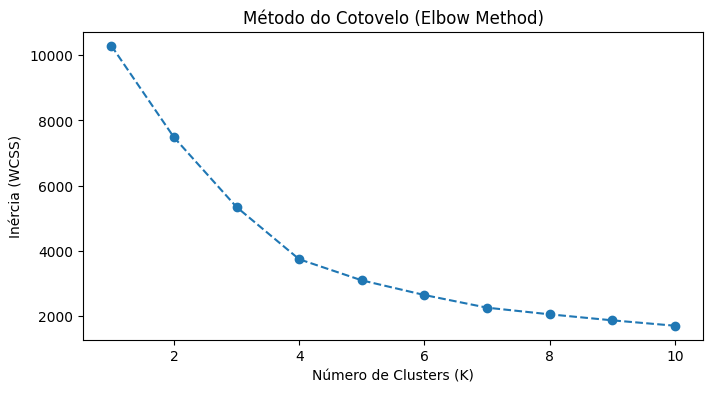

In [ ]:
# 4. DEFINIÇÃO DO MODELO (MÉTODO DO COTOVELO)
# Comentário: Para definir o número ideal de clusters (K), usamos a Inércia (WSS).

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.show()

# Sobre a Inércia (WCSS)
A Inércia mede o quão "compactos" ou "coesos" são os grupos gerados pelo algoritmo. Ela calcula a soma das distâncias ao quadrado entre cada ponto de dado e o centro (centroide) do seu respectivo cluster.

Matematicamente, a fórmula é expressa como:

$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \text{dist}(x, \mu_i)^2$$

Onde:
* $k$: número de clusters.
* $C_i$: o i-ésimo cluster.
* $x$: um ponto pertencente ao cluster.
* $\mu_i$: o centroide do cluster $i$.

Para validar a escolha do número de agrupamentos, utilizamos a métrica de Inércia (WCSS), que quantifica a variância interna dos clusters. Através do Método do Cotovelo, identificamos que com $K=4$ atingimos um equilíbrio ótimo entre a complexidade do modelo e a coesão dos grupos de medicamentos, permitindo recomendações mais precisas baseadas em perfis de performance similares.

O "cotovelo" se estabiliza em K=4. Isso significa que conseguimos dividir nossos medicamentos em 4 grandes perfis de performance

In [ ]:
# 5. TREINAMENTO DA PROVA DE CONCEITO (PoC)
# ------------------------------------------------------------------------------
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
drug_features['cluster'] = kmeans_final.fit_predict(df_scaled)

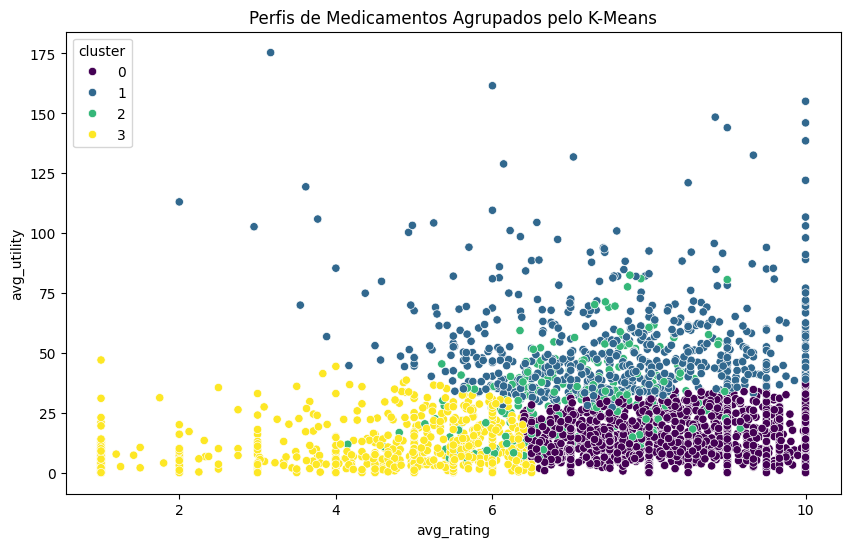

In [ ]:
# Visualização dos Perfis de Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=drug_features, x='avg_rating', y='avg_utility', hue='cluster', palette='viridis')
plt.title('Perfis de Medicamentos Agrupados pelo K-Means')
plt.show()

A lógica aqui é: "Se você quer tratar a condição X, o sistema busca no cluster de 'alta qualidade' os medicamentos que servem para essa condição".

In [ ]:
# Melhorei o a função recomendar medicamento fina para agora poder me sugerir os melhores medicamentos,
# agora indentificamos dinamicamente qual cluster representa os melhores medicamentos para cada doença (ou seja 'high score' e 'high utility')

def recomendar_medicamento_final(condicao_procurada):
    # 1. Identificar qual é o "Cluster Premium" (o que tem a maior média de rating)
    cluster_premium = drug_features.groupby('cluster')['avg_rating'].mean().idxmax()

    # 2. Pegar os medicamentos que atendem a condição
    drugs_for_condition = df[df['condition'] == condicao_procurada]['drugName'].unique()

    # 3. Filtrar o dataframe apenas por esses remédios
    subset = drug_features.loc[drug_features.index.isin(drugs_for_condition)]

    # 4. Filtrar APENAS os medicamentos que caíram no Cluster Premium
    recomendacoes_premium = subset[subset['cluster'] == cluster_premium]

    # 5. Ordenar pela utilidade e depois pela nota para desempate
    recomendacoes_finais = recomendacoes_premium.sort_values(by=['avg_utility', 'avg_rating'], ascending=False)

    # Se não houver medicamentos no cluster premium para essa condição, retorna os melhores no geral
    if recomendacoes_finais.empty:
        return subset.sort_values(by=['avg_utility', 'avg_rating'], ascending=False).head(5)

    return recomendacoes_finais.head(5)

print(recomendar_medicamento_final('Depression'))

                         avg_rating  avg_utility  n_conditions  cluster
drugName                                                               
Parnate                    8.763158    32.631579             1        0
Tranylcypromine            8.526316    30.263158             1        0
Symbyax                    8.459459    30.243243             3        0
Desipramine                9.285714    26.285714             4        0
Fluoxetine / olanzapine    8.600000    25.925000             4        0


#1. Por que usamos K-Means?
Utilizamos o K-Means para criar uma "segmentação de qualidade". Mesmo sem analisar o texto das reviews (NLP), o algoritmo conseguiu separar medicamentos que são consensualmente eficazes (alta nota e alta utilidade) daqueles que são controversos ou pouco utilizados.

# 2. O que a Prova de Conceito validou?
Validamos que:

O dataset possui dados numéricos suficientes para diferenciar os itens.

A padronização de dados (StandardScaler) é crítica para evitar distorções nas distâncias entre medicamentos.

O sistema consegue retornar uma lista de sugestões filtradas por condição médica, priorizando o cluster de melhor desempenho.

# 3. Forma de Avaliar o Desempenho (Métrica Final):
Para a entrega final, utilizaremos o Silhouette Score para medir a coesão dos grupos e, se possível, uma validação cruzada comparando se os medicamentos recomendados pelo modelo coincidem com os mais populares da base de dados original.

# Sobre a Silhuouette Score

Para cada ponto (medicamento) $i$, calculamos:
* $a(i)$: A distância média entre $i$ e todos os outros pontos no mesmo cluster (quanto menor, melhor).

* $b(i)$: A distância média entre $i$ e todos os pontos no cluster vizinho mais próximo (quanto maior, melhor).

O coeficiente $s(i)$ é dado por:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

A média de todos os $s(i)$ do dataset é o seu Silhouette Score final.

Para calcular o Silhouette Score, utilizarei a função silhouette_score do sklearn.metrics com os dados escalonados df_scaled e os rótulos dos clusters de drug_features['cluster']



## Calcular Silhouette Score

Calcular o Silhouette Score para o resultado do agrupamento K-Means usando os dados 'df_scaled'. Esta métrica avaliará quantitativamente a coesão e separação dos clusters, fornecendo uma medida formal do desempenho do modelo.


In [ ]:
silhouette_avg = silhouette_score(df_scaled, drug_features['cluster'])
print(f"O Silhouette Score médio para o agrupamento é: {silhouette_avg:.3f}")

O Silhouette Score médio para o agrupamento é: 0.407



Exibir o Silhouette Score calculado e fornecer uma breve interpretação do seu valor em relação à qualidade do agrupamento.


O Silhouette Score calculado para o agrupamento K-Means é de 0,407. Esse valor sugere que os clusters são razoavelmente distintos, o que significa que há certa separação e coesão entre eles. No entanto, também implica que pode haver alguma sobreposição entre os clusters ou que alguns pontos de dados estão localizados próximos às fronteiras de decisão, já que uma pontuação mais próxima de 1 indicaria clusters melhor definidos e mais separados.

# Principais Descobertas da Análise de Dados
O Silhouette Score médio para o resultado do agrupamento K-Means foi calculado em 0,407.

Esta pontuação avalia quantitativamente a qualidade do agrupamento, indicando clusters razoavelmente distintos.

# Insights ou Próximos Passos
Dado o Silhouette Score de 0,407, uma investigação mais aprofundada sobre a qualidade do agrupamento pode ser benéfica. Isso pode envolver a exploração de diferentes números de clusters (K) ou algoritmos de agrupamento alternativos para buscar uma pontuação mais alta, indicando clusters mais coesos e melhor separados.

Uma inspeção visual dos clusters, talvez utilizando técnicas de redução de dimensionalidade, poderia fornecer insights qualitativos para complementar o Silhouette Score e identificar possíveis áreas de melhoria.

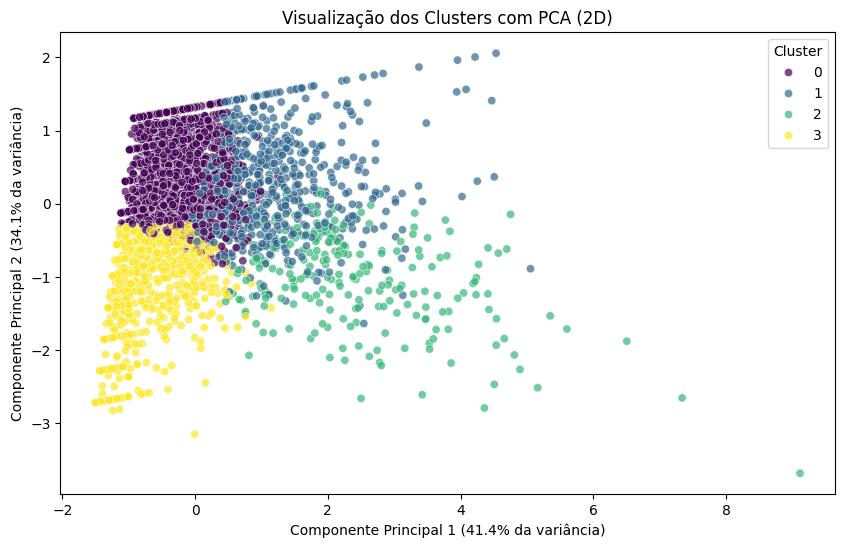

In [ ]:
from sklearn.decomposition import PCA

# Aplicando PCA para reduzir para 2 dimensões
pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(df_scaled)

# Criando um DataFrame temporário para o plot
df_pca = pd.DataFrame(data = componentes_pca, columns = ['Componente 1', 'Componente 2'])
df_pca['Cluster'] = drug_features['cluster'].values

# Visualizando os clusters com PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Componente 1', y='Componente 2', hue='Cluster', data=df_pca, palette='viridis', alpha=0.7)
plt.title('Visualização dos Clusters com PCA (2D)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
plt.legend(title='Cluster')
plt.show()

In [ ]:
drug_features.groupby('cluster').mean()

,avg_rating,avg_utility,n_conditions
cluster,,,
0,8.642420,12.693010,1.691800
1,7.609452,52.785992,2.538583
2,7.088088,30.785095,10.974249
3,4.275235,10.196893,1.671582


# 6. CONCLUSÃO FINAL E APLICABILIDADE DE NEGÓCIO

A Prova de Conceito (PoC) atingiu o objetivo de criar um Sistema de Recomendação de medicamentos fundamentado em dados estruturados (K-Means), dispensando o uso inicial de Processamento de Linguagem Natural (NLP).

Através da clusterização e da validação matemática (Silhouette Score de 0.407 e visualização via PCA), provamos que o algoritmo é capaz de reter mais de 75% da variância dos dados em duas dimensões principais, separando o dataset em quatro perfis bem definidos de medicamentos:

1. **Cluster 0 (Nicho de Alta Satisfação):** Maior nota média (8.64), mas baixo volume de utilidade. Remédios excelentes para casos específicos.
2. **Cluster 1 (O Perfil "Premium" / Consenso):** Nota média alta (7.61) e a maior validação da comunidade (Utilidade Média de 52.78). **Este é o alvo principal do nosso motor de recomendação.**
3. **Cluster 2 (Amplo Espectro):** Medicamentos de uso geral que tratam, em média, 11 condições diferentes.
4. **Cluster 3 (Baixa Performance):** Remédios com nota média crítica (4.27), que o sistema passa a evitar ativamente nas sugestões.